<a href="https://colab.research.google.com/github/neomatekane/FUTURE_DS_01/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

zip_path = "/content/drive/MyDrive/2019-Nov.csv.zip"

df_iter = pd.read_csv(zip_path, compression='zip', chunksize=500000)

# Read first chunk only
df = next(df_iter)

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [2]:
df_sample = df.sample(100000, random_state=42)

In [3]:
cols = ['event_time', 'event_type', 'category_id', 'price']

df_iter = pd.read_csv(
    zip_path,
    compression='zip',
    usecols=cols,
    chunksize=500000
)

df = next(df_iter)

In [4]:
funnel_counts = {'view': 0, 'cart': 0, 'purchase': 0}#build funnel from chunk data

for chunk in pd.read_csv(zip_path, compression='zip', chunksize=500000):
    counts = chunk['event_type'].value_counts()

    for key in funnel_counts:
        funnel_counts[key] += counts.get(key, 0)

print(funnel_counts)

{'view': np.int64(63556110), 'cart': np.int64(3028930), 'purchase': np.int64(916939)}


In [5]:
visitors = funnel_counts['view']
leads = funnel_counts['cart']
customers = funnel_counts['purchase']

In [6]:
import pandas as pd

zip_path = "/content/drive/MyDrive/2019-Nov.csv.zip"

# Initialize counters
funnel_counts = {'view': 0, 'cart': 0, 'purchase': 0}

# Optional: category-level tracking
category_data = {}

for chunk in pd.read_csv(zip_path, compression='zip', chunksize=500000):

    # Count funnel stages
    counts = chunk['event_type'].value_counts()

    for stage in funnel_counts:
        funnel_counts[stage] += counts.get(stage, 0)

    # Category-level aggregation
    grouped = chunk.groupby(['category_id', 'event_type']).size()

    for (cat, event), value in grouped.items():
        if cat not in category_data:
            category_data[cat] = {'view': 0, 'cart': 0, 'purchase': 0}
        category_data[cat][event] += value

# Final totals
visitors = funnel_counts['view']
leads = funnel_counts['cart']
customers = funnel_counts['purchase']

In [7]:
visit_to_lead = leads / visitors #conversion rates
lead_to_customer = customers / leads

In [8]:
drop_visit = 1 - visit_to_lead #drop off rates
drop_lead = 1 - lead_to_customer

In [9]:
category_df = pd.DataFrame.from_dict(category_data, orient='index')#catergory performance

category_df['visit_to_lead'] = category_df['cart'] / category_df['view']
category_df['lead_to_customer'] = category_df['purchase'] / category_df['cart']

top_categories = category_df.sort_values('lead_to_customer', ascending=False).head(10)

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

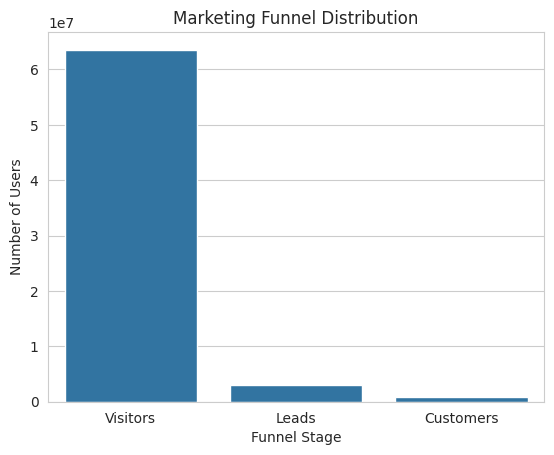

In [11]:
stages = ['Visitors', 'Leads', 'Customers'] #Funnel visuals
values = [visitors, leads, customers]

sns.barplot(x=stages, y=values)

plt.title("Marketing Funnel Distribution")
plt.ylabel("Number of Users")
plt.xlabel("Funnel Stage")
plt.show()

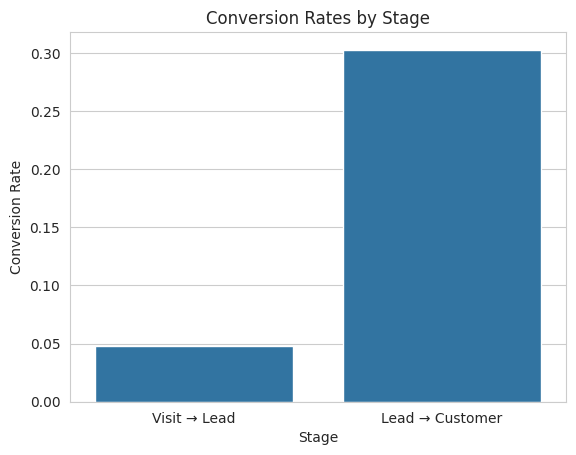

In [12]:
conversion_df = pd.DataFrame({
    'Stage': ['Visit → Lead', 'Lead → Customer'],
    'Conversion Rate': [visit_to_lead, lead_to_customer]
}) #conversion rates

sns.barplot(data=conversion_df, x='Stage', y='Conversion Rate')

plt.title("Conversion Rates by Stage")
plt.ylabel("Conversion Rate")
plt.show()

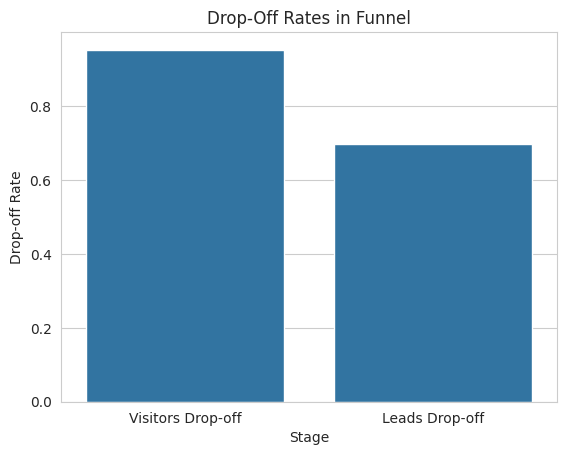

In [13]:
dropoff_df = pd.DataFrame({
    'Stage': ['Visitors Drop-off', 'Leads Drop-off'],
    'Drop-off Rate': [drop_visit, drop_lead]
}) #drop off rates visuals


sns.barplot(data=dropoff_df, x='Stage', y='Drop-off Rate')

plt.title("Drop-Off Rates in Funnel")
plt.ylabel("Drop-off Rate")
plt.show()

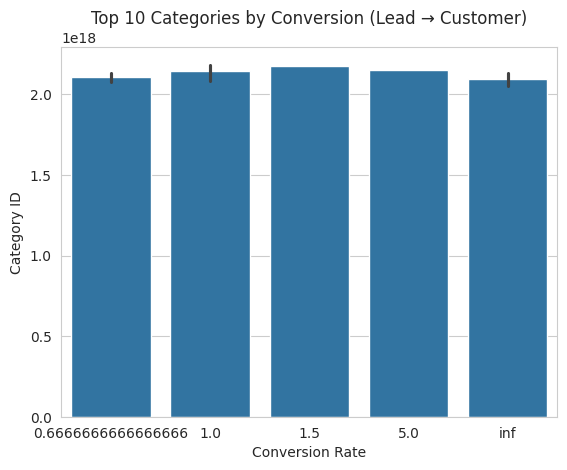

In [14]:
top_categories = category_df.sort_values('lead_to_customer', ascending=False).head(10)

sns.barplot(
    data=top_categories.reset_index(),
    x='lead_to_customer',
    y='index'
) #top-categories visuals

plt.title("Top 10 Categories by Conversion (Lead → Customer)")
plt.xlabel("Conversion Rate")
plt.ylabel("Category ID")
plt.show()

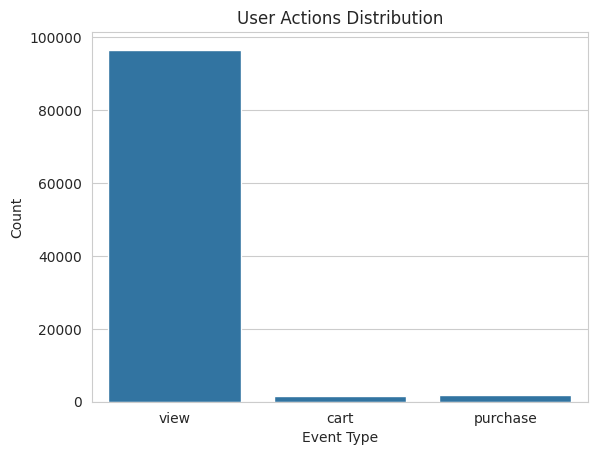

In [16]:
sns.countplot(data=df_sample, x='event_type') #event-time distribution

plt.title("User Actions Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

In [26]:
import pandas as pd

zip_path = "/content/drive/MyDrive/2019-Nov.csv.zip"

time_dict = {}

for chunk in pd.read_csv(zip_path, compression='zip', chunksize=500000):

    chunk['event_time'] = pd.to_datetime(chunk['event_time'], errors='coerce')
    chunk['date'] = chunk['event_time'].dt.date

    grouped = chunk.groupby(['date', 'event_type']).size()

    for (date, event), value in grouped.items():
        if date not in time_dict:
            time_dict[date] = {'view': 0, 'cart': 0, 'purchase': 0}
        time_dict[date][event] += value

In [27]:
time_df = pd.DataFrame.from_dict(time_dict, orient='index')

time_df = time_df.fillna(0).sort_index()
time_df = time_df.reset_index().rename(columns={'index': 'date'})

In [28]:
time_melted = time_df.melt(id_vars='date',
                          var_name='event_type',
                          value_name='count')

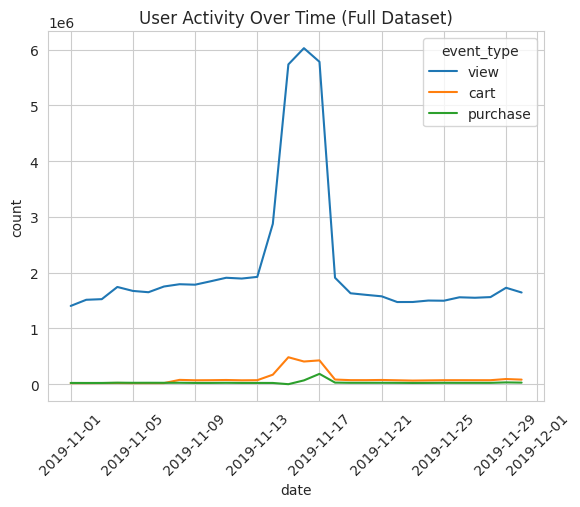

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=time_melted, x='date', y='count', hue='event_type')

plt.title("User Activity Over Time (Full Dataset)")
plt.xticks(rotation=45)
plt.show()